# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

Автор: Кезлинг Владислав

Дата: 27.03.2026

------------
**Цель:** 
- Разработать модель машинного обучения для предсказания оттока клиентов сервиса доставки кофе.

**Задачи:**
- Провести исследовательский анализ данных, выполнить предобработку с созданием новых признаков и обучить логистическую регрессию с подбором гиперпараметров.

**Критерии успешности:**
- Достижение максимально возможного значения метрики PR_AUC.
- Сохранить лучшую и стабильную модель (включая пайплайн) для продакшена.

---------------

# План работы

## Этап 1. Подготовка среды и библиотек
1. Установите и настройте библиотеки. Для воспроизводимости результатов зафиксируйте версии пакетов в файле `requirements.txt`.

2. Зафиксируйте `random_state`.

3. Загрузите данные из CSV-файла. Путь к файлу: `'/datasets/coffee_churn_dataset.csv'`. Используйте сепаратор `","`, а для чтения чисел с плавающей точкой — параметр `decimal="."`.

### 1

In [1]:
# Исправления, дополнения, поправки по комментариям
# ---------------------------------------------------------
# установка необходимых библиотек (добавлен флаг, чтобы не показывались логи)
!pip install pandas -q
!pip install scikit-learn -q
!pip install joblib -q
!pip install matplotlib -q
!pip install seaborn -q
# ---------------------------------------------------------

# импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
import seaborn as sns
import joblib

# skleaern
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import average_precision_score, f1_score

# проверка версий для requirements.txt
# !pip freeze > requirements.txt

# Исправления, дополнения, поправки по комментариям
# ---------------------------------------------------------
# вывод, чтобы удостоверится, что процесс выполнен
print('Выполнено')
# ---------------------------------------------------------

Выполнено


### 2

In [2]:
# фиксируем random_state
RANDOM_STATE = 42

### 3

In [3]:
# загружаем и создаём датафрейм
df = pd.read_csv('datasets/coffee_churn_dataset.csv', sep=',', decimal='.')

# общая информация
print("Размер датасета:", df.shape)
print("Количество строк:", df.shape[0])
print("Количество столбцов:", df.shape[1])
print("\nНазвания столбцов:")
print(df.columns.tolist())

# тип данных
print('\n', 'Тип:')
print(df.dtypes)

# первые 5 строк для проверки
df.head()

Размер датасета: (10450, 27)
Количество строк: 10450
Количество столбцов: 27

Названия столбцов:
['user_id', 'days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'seasons', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location', 'churn']

 Тип:
user_id                      object
days_since_last_order       float64
order_frequency_month       float64
order_frequency_week        float64
avg_order_value             float64
median_order_value          float64
total_spent_last_month      float64
total_spent_last_week       float64
discount_usage_rate         float64
l

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


**Промежуточный вывод:** 
- Установлены и импортированны необходимые библиотеки.
- Зафиксирован random_state для воспроизводимости результатов.
- Загружен датасет и основная информация о нём.

-----------------------

## Этап 2. Первичный анализ данных

1. Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

2. Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

3. Опишите признаки.

   - Определите, все ли из них важны.

   - Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

4. Обработайте пропущенные значения.
   
   - Объясните, как они влияют на данные.

   - Выберите стратегию заполнения пропусков.

5. Проанализируйте категориальные признаки.

   - Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.

   - Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых  признаков. Укажите возможные стратегии.

   - Определите, есть ли в данных признаки, которые можно удалить.

6. Проанализируйте выбросы.

   - Определите, как они влияют на данные.

   - Выберите способ, которым их можно обработать.

7. Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.

8. Напишите выводы по результатам исследовательского анализа данных.

### 1)
Опишите данные. Кратко сообщите, что известно о пользователях и их поведении.

In [4]:
# краткая информация
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

In [5]:
# описание данных
df.describe().round(2)

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.00,9850.00,10062.00,9867.00,9619.00,10156.00,9506.00,10053.00,9461.00,9554.00,9913.00,9757.00,9593.00,9729.00,9719.00,9840.00,10450.00
mean,4.39,4.03,0.93,1063.74,452.65,1946.13,413.00,0.28,0.70,11.33,0.75,4.21,4.02,1.01,14.55,0.19,0.06
std,4.86,2.83,0.66,707.71,258.66,2370.62,445.63,0.16,0.46,14.53,0.43,0.78,1.21,1.01,15.31,0.39,0.24
min,0.00,0.01,-0.17,-32.08,-10.35,-43.72,-2290.56,0.00,0.00,0.00,0.00,1.42,-0.90,0.00,0.00,0.00,0.00
25%,1.00,1.94,0.45,552.90,262.91,629.68,136.57,0.16,0.00,6.31,1.00,3.68,3.21,0.00,4.00,0.00,0.00
50%,3.00,3.38,0.78,898.64,406.46,1300.41,288.28,0.26,1.00,9.23,1.00,4.20,3.99,1.00,10.00,0.00,0.00
75%,6.00,5.44,1.26,1406.33,590.42,2481.65,549.70,0.39,1.00,12.73,1.00,4.72,4.85,2.00,20.00,0.00,0.00
max,40.00,27.39,6.30,5901.97,2189.10,79298.85,8615.99,0.89,1.00,224.59,1.00,7.38,8.56,7.00,140.00,1.00,1.00


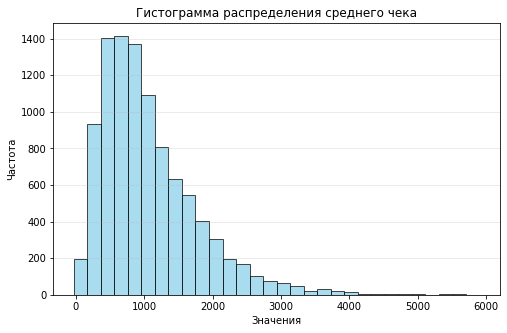

In [6]:
# гистограмма распределения среднего чека (просто проверить)
plt.figure(figsize=(8, 5))
plt.hist(df['avg_order_value'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения среднего чека')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()

**Промежуточный вывод:**
- Всего 10450 пользователей.
- В среднем пользователь делает 4 заказа в месяц. 
- Средний чек 1063руб. Медиана 898руб., значит есть пользователи, которые тратят значительно больше остальных.
- В среднем пользователи открывают приложение 11 раз в неделю, но есть тот, кто открыл 224 раза - это, возможно ошибка, а возможно, что данный пользователь очень любит кофе.

(Также, обнаружены отрицательные значения)

### 2)
Опишите целевую переменную. Обратите внимание на возможные особенности её распределения. Проверьте, наблюдается ли дисбаланс классов в целевой переменной.

In [7]:
# описание данных (ещё раз)
df.describe().round(2)

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.00,9850.00,10062.00,9867.00,9619.00,10156.00,9506.00,10053.00,9461.00,9554.00,9913.00,9757.00,9593.00,9729.00,9719.00,9840.00,10450.00
mean,4.39,4.03,0.93,1063.74,452.65,1946.13,413.00,0.28,0.70,11.33,0.75,4.21,4.02,1.01,14.55,0.19,0.06
std,4.86,2.83,0.66,707.71,258.66,2370.62,445.63,0.16,0.46,14.53,0.43,0.78,1.21,1.01,15.31,0.39,0.24
min,0.00,0.01,-0.17,-32.08,-10.35,-43.72,-2290.56,0.00,0.00,0.00,0.00,1.42,-0.90,0.00,0.00,0.00,0.00
25%,1.00,1.94,0.45,552.90,262.91,629.68,136.57,0.16,0.00,6.31,1.00,3.68,3.21,0.00,4.00,0.00,0.00
50%,3.00,3.38,0.78,898.64,406.46,1300.41,288.28,0.26,1.00,9.23,1.00,4.20,3.99,1.00,10.00,0.00,0.00
75%,6.00,5.44,1.26,1406.33,590.42,2481.65,549.70,0.39,1.00,12.73,1.00,4.72,4.85,2.00,20.00,0.00,0.00
max,40.00,27.39,6.30,5901.97,2189.10,79298.85,8615.99,0.89,1.00,224.59,1.00,7.38,8.56,7.00,140.00,1.00,1.00


In [8]:
# проверка чисами
counts = df['churn'].value_counts()
percent = df['churn'].value_counts(normalize=True) * 100

print("Количество:")
print(counts)
print("\nПроцентное соотношение:")
print(percent)

Количество:
churn
0    9821
1     629
Name: count, dtype: int64

Процентное соотношение:
churn
0    93.980861
1     6.019139
Name: proportion, dtype: float64


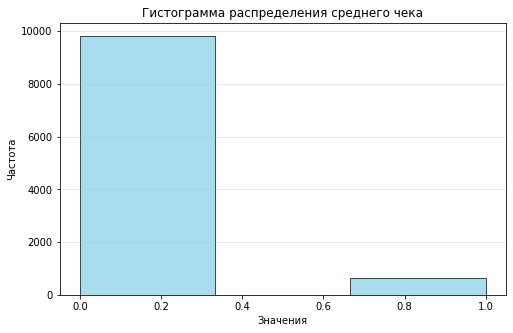

In [9]:
# гистограмма распределения churn 
plt.figure(figsize=(8, 5))
plt.hist(df['churn'], bins=3, color='skyblue', edgecolor='black', alpha=0.7)

plt.title('Гистограмма распределения среднего чека')
plt.xlabel('Значения')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.3)

plt.show()

**Промежуточный вывод:**
- В целевой переменной сильный дизбаланс классов, всего около 6% ушли. (Главня метрика PR_AUC)

### 3)
Опишите признаки:
- Определите, все ли из них важны.
- Объясните, какие из них можно удалить (если такие есть). Аргументируйте своё решение.

In [10]:
# ещй раз посмотрим на развания столбцов и проверим их описание из условия
print("Размер датасета:", df.shape)
print("\nНазвания столбцов:")
print(df.columns.tolist())

Размер датасета: (10450, 27)

Названия столбцов:
['user_id', 'days_since_last_order', 'order_frequency_month', 'order_frequency_week', 'avg_order_value', 'median_order_value', 'total_spent_last_month', 'total_spent_last_week', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'seasons', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location', 'churn']


In [11]:
# проверим уникальные значения 
df['geo_location'].unique()

array(['geo_75', 'geo_95', 'geo_25', 'geo_2', 'geo_19', 'geo_68', 'geo_3',
       'geo_45', 'geo_15', nan, 'geo_30', 'geo_93', 'geo_64', 'geo_40',
       'geo_87', 'geo_17', 'geo_11', 'geo_94', 'geo_1', 'geo_50',
       'geo_67', 'geo_51', 'geo_97', 'geo_16', 'geo_78', 'geo_100',
       'geo_98', 'geo_43', 'geo_8', 'geo_48', 'geo_61', 'geo_74',
       'geo_35', 'geo_59', 'geo_46', 'geo_5', 'geo_23', 'geo_91',
       'geo_42', 'geo_90', 'geo_4', 'geo_96', 'geo_57', 'geo_71',
       'geo_54', 'geo_65', 'geo_32', 'geo_14', 'geo_72', 'geo_29',
       'geo_9', 'geo_83', 'geo_12', 'geo_76', 'geo_92', 'geo_84',
       'geo_31', 'geo_34', 'geo_41', 'geo_18', 'geo_24', 'geo_85',
       'geo_49', 'geo_69', 'geo_47', 'geo_86', 'geo_99', 'geo_36',
       'geo_79', 'geo_26', 'geo_73', 'geo_13', 'geo_10', 'geo_58',
       'geo_63', 'geo_82', 'geo_22', 'geo_39', 'geo_81', 'geo_21',
       'geo_27', 'geo_33', 'geo_20', 'geo_60', 'geo_53', 'geo_88',
       'geo_62', 'geo_70', 'geo_28', 'geo_56', 'geo_5

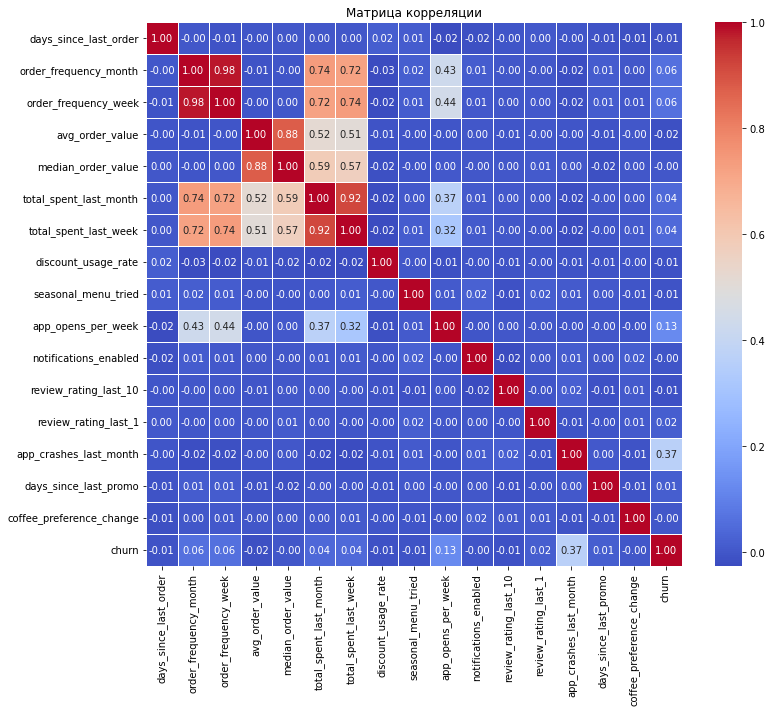

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(method='spearman', numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции')
plt.show()

**Промежуточный вывод**
- признак 'user_id' - нужно удалить, так как он будет создавать шум. 
- признак 'order_frequency_week' - нужно удалить, так как он очень сильно корелирует с "order_frequency_month", но второй будет постабильнее.
- признак 'avg_order_value' - нужно удалить, так как он очень сильно корелирует с "median_order_value", но второй будет постабильнее.
--------------
- total_spent_last_month и total_spent_last_week: эти признаки сильно коррелируют и с частотой заказов, и со средним чеком.

In [13]:
# удаляем признаки и смотрим размер
cols_to_drop = ['user_id', 'order_frequency_week', 'avg_order_value', 
                'total_spent_last_month', 'total_spent_last_week']
df_filtred = df.drop(columns=cols_to_drop)

print("Размер датасета:", df_filtred.shape)
print("\nНазвания столбцов:")
print(df_filtred.columns.tolist())

Размер датасета: (10450, 22)

Названия столбцов:
['days_since_last_order', 'order_frequency_month', 'median_order_value', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'seasons', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location', 'churn']


**Признаки были удалены**

### 4

Обработайте пропущенные значения:
- Объясните, как они влияют на данные.
- Выберите стратегию заполнения пропусков.

In [14]:
#размер до пропусков
print("Размер датасета:", df.shape)

# ищем пропуски
df_filtred.isnull().sum()

Размер датасета: (10450, 27)


days_since_last_order       945
order_frequency_month       600
median_order_value          831
discount_usage_rate         397
last_coffee_type            258
preferred_roast             116
milk_preference             668
seasonal_menu_tried         989
coffee_bean_origin          682
last_drink_size             504
subscription_status         938
app_opens_per_week          896
notifications_enabled       537
review_rating_last_10       693
review_rating_last_1        857
app_crashes_last_month      721
seasons                     679
days_since_last_promo       731
phone_type                  336
coffee_preference_change    610
geo_location                110
churn                         0
dtype: int64

In [15]:
# процент пропусков и сортируем по убыванию
mis_pct = (df_filtred.isnull().sum() / len(df_filtred)) * 100
print(mis_pct.sort_values(ascending=False).round(2))

seasonal_menu_tried         9.46
days_since_last_order       9.04
subscription_status         8.98
app_opens_per_week          8.57
review_rating_last_1        8.20
median_order_value          7.95
days_since_last_promo       7.00
app_crashes_last_month      6.90
review_rating_last_10       6.63
coffee_bean_origin          6.53
seasons                     6.50
milk_preference             6.39
coffee_preference_change    5.84
order_frequency_month       5.74
notifications_enabled       5.14
last_drink_size             4.82
discount_usage_rate         3.80
phone_type                  3.22
last_coffee_type            2.47
preferred_roast             1.11
geo_location                1.05
churn                       0.00
dtype: float64


In [16]:
# проверка отдельного поля
df_filtred['subscription_status'].unique()

array(['pro', 'none', 'premium', 'basic', nan], dtype=object)

**Промежуточный вывод:**
- В данных, обнаружены пропуски, так как их достаточно много (в целом), то "просто" удалить их нельзя, нужно обработать. Иначе, они могут "перетянуть" веса, создать ложные закономерности, также многие модели не могут работать с пропусками (модель не обучится)
--------------
- В катигориальных признаках использовать заполнение по моде (SimpleImputer(strategy='most_frequent')).
- В числовых заполнить медианой (SimpleImputer(strategy='median'))
--------------
- Для признака subscription_status пропуск может означать отсутствие подписки, поэтому лучше заполненить константой 'none'. 

### 5

Проанализируйте категориальные признаки:
- Выясните, есть ли в данных признаки, которые можно кодировать. Объясните, почему именно их нужно кодировать.
- Проанализируйте признаки на предмет того, можно ли использовать некоторые из них для генерации новых признаков. Укажите возможные стратегии.
- Определите, есть ли в данных признаки, которые можно удалить.


In [17]:
#размер
print("Размер датасета:", df_filtred.shape)

# краткая информация
print('\n')
df_filtred.info()

Размер датасета: (10450, 22)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float64
 1   order_frequency_month     9850 non-null   float64
 2   median_order_value        9619 non-null   float64
 3   discount_usage_rate       10053 non-null  float64
 4   last_coffee_type          10192 non-null  object 
 5   preferred_roast           10334 non-null  object 
 6   milk_preference           9782 non-null   object 
 7   seasonal_menu_tried       9461 non-null   float64
 8   coffee_bean_origin        9768 non-null   object 
 9   last_drink_size           9946 non-null   object 
 10  subscription_status       9512 non-null   object 
 11  app_opens_per_week        9554 non-null   float64
 12  notifications_enabled     9913 non-null   float64
 13  review_rating_last_10     9757

In [18]:
# смотрим уникальные значения
cols = ['last_coffee_type', 'preferred_roast', 'milk_preference', 
            'coffee_bean_origin', 'last_drink_size', 'subscription_status',
           'seasons', 'phone_type']

for col in cols:
    print(f"{col}: {df_filtred[col].unique()}")

last_coffee_type: ['blend' 'arabica' 'robusta' nan]
preferred_roast: ['light' 'medium' 'dark' nan]
milk_preference: ['almond' 'whole' 'oat' 'skim' 'soy' nan 'none']
coffee_bean_origin: ['vietnam' 'guatemala' 'brazil' 'colombia' 'kenya' nan 'ethiopia']
last_drink_size: ['large' 'medium' 'small' nan]
subscription_status: ['pro' 'none' 'premium' 'basic' nan]
seasons: ['summer' 'autumn' 'spring' 'winter' nan]
phone_type: ['android' 'ios' 'web' nan]


In [19]:
df_filtred[['last_coffee_type', 'preferred_roast', 'milk_preference', 
            'coffee_bean_origin', 'last_drink_size', 'subscription_status',
           'seasons', 'phone_type']].head()

,last_coffee_type,preferred_roast,milk_preference,coffee_bean_origin,last_drink_size,subscription_status,seasons,phone_type
0,blend,light,almond,vietnam,large,pro,summer,android
1,arabica,light,whole,guatemala,medium,none,autumn,ios
2,arabica,medium,oat,guatemala,small,premium,spring,web
3,robusta,medium,skim,brazil,medium,none,summer,android
4,robusta,dark,almond,colombia,medium,none,winter,ios


In [20]:
print("Размер датасета:", df_filtred.shape)
print("\nНазвания столбцов:")
print(df_filtred.columns.tolist())
#размер
print("Размер датасета:", df_filtred.shape)

Размер датасета: (10450, 22)

Названия столбцов:
['days_since_last_order', 'order_frequency_month', 'median_order_value', 'discount_usage_rate', 'last_coffee_type', 'preferred_roast', 'milk_preference', 'seasonal_menu_tried', 'coffee_bean_origin', 'last_drink_size', 'subscription_status', 'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10', 'review_rating_last_1', 'app_crashes_last_month', 'seasons', 'days_since_last_promo', 'phone_type', 'coffee_preference_change', 'geo_location', 'churn']
Размер датасета: (10450, 22)


**Промежуточный вывод:** 
- В данных есть признаки, которые необходимо кодировать, это необходимо сделать, иначе модель не будет работать (или проигнорирует эти данные).
---------------
- (Данные, новые признаки будут созданы и использоваться для обучения "улучшенной" модели)
- Новый признак: promo_res - оттношение discount_usage_rate к days_since_last_promo, чтобы понять, как пользователь использует скидку после получения.
- Новый признак: rating_drop -  разница между review_rating_last_10 и review_rating_last_1, чтобы понять падение рейтинга.
----------
- Признаки, которые можно удалить на данном этапе не обнаружено, но после создания новых, это нужно будет перепроверить.

### 6

Проанализируйте выбросы:
- Определите, как они влияют на данные.
- Выберите способ, которым их можно обработать.

In [21]:
df_filtred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float64
 1   order_frequency_month     9850 non-null   float64
 2   median_order_value        9619 non-null   float64
 3   discount_usage_rate       10053 non-null  float64
 4   last_coffee_type          10192 non-null  object 
 5   preferred_roast           10334 non-null  object 
 6   milk_preference           9782 non-null   object 
 7   seasonal_menu_tried       9461 non-null   float64
 8   coffee_bean_origin        9768 non-null   object 
 9   last_drink_size           9946 non-null   object 
 10  subscription_status       9512 non-null   object 
 11  app_opens_per_week        9554 non-null   float64
 12  notifications_enabled     9913 non-null   float64
 13  review_rating_last_10     9757 non-null   float64
 14  review

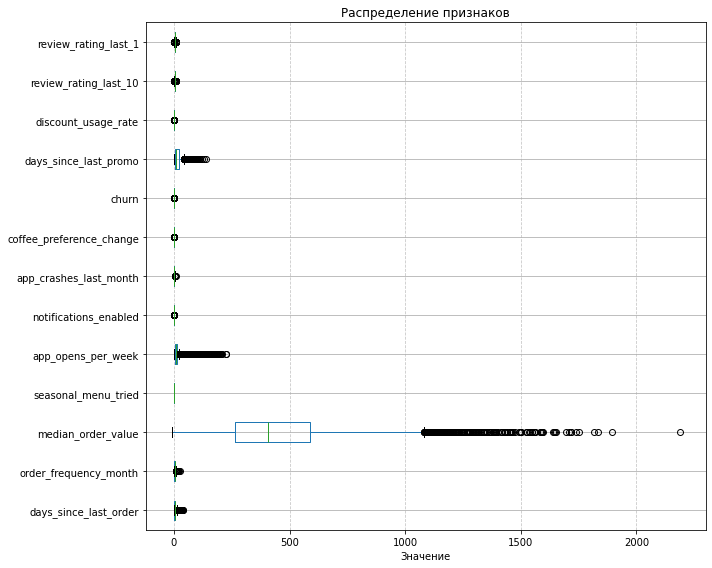

In [22]:
# Исправления, дополнения, поправки по комментариям (убрал "новые" признаки, вернул "старые")
# ---------------------------------------------------------
# смотрим распределение признаков, boxplot
plt.figure(figsize=(10, 8))

df_filtred.boxplot(column=['days_since_last_order', 'order_frequency_month', 'median_order_value', 
                            'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 
                           'app_crashes_last_month', 'coffee_preference_change', 'churn', 
                           'days_since_last_promo', 'discount_usage_rate', 'review_rating_last_10', 
                           'review_rating_last_1'], vert=False)

plt.title('Распределение признаков')
plt.xlabel('Значение')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# ---------------------------------------------------------

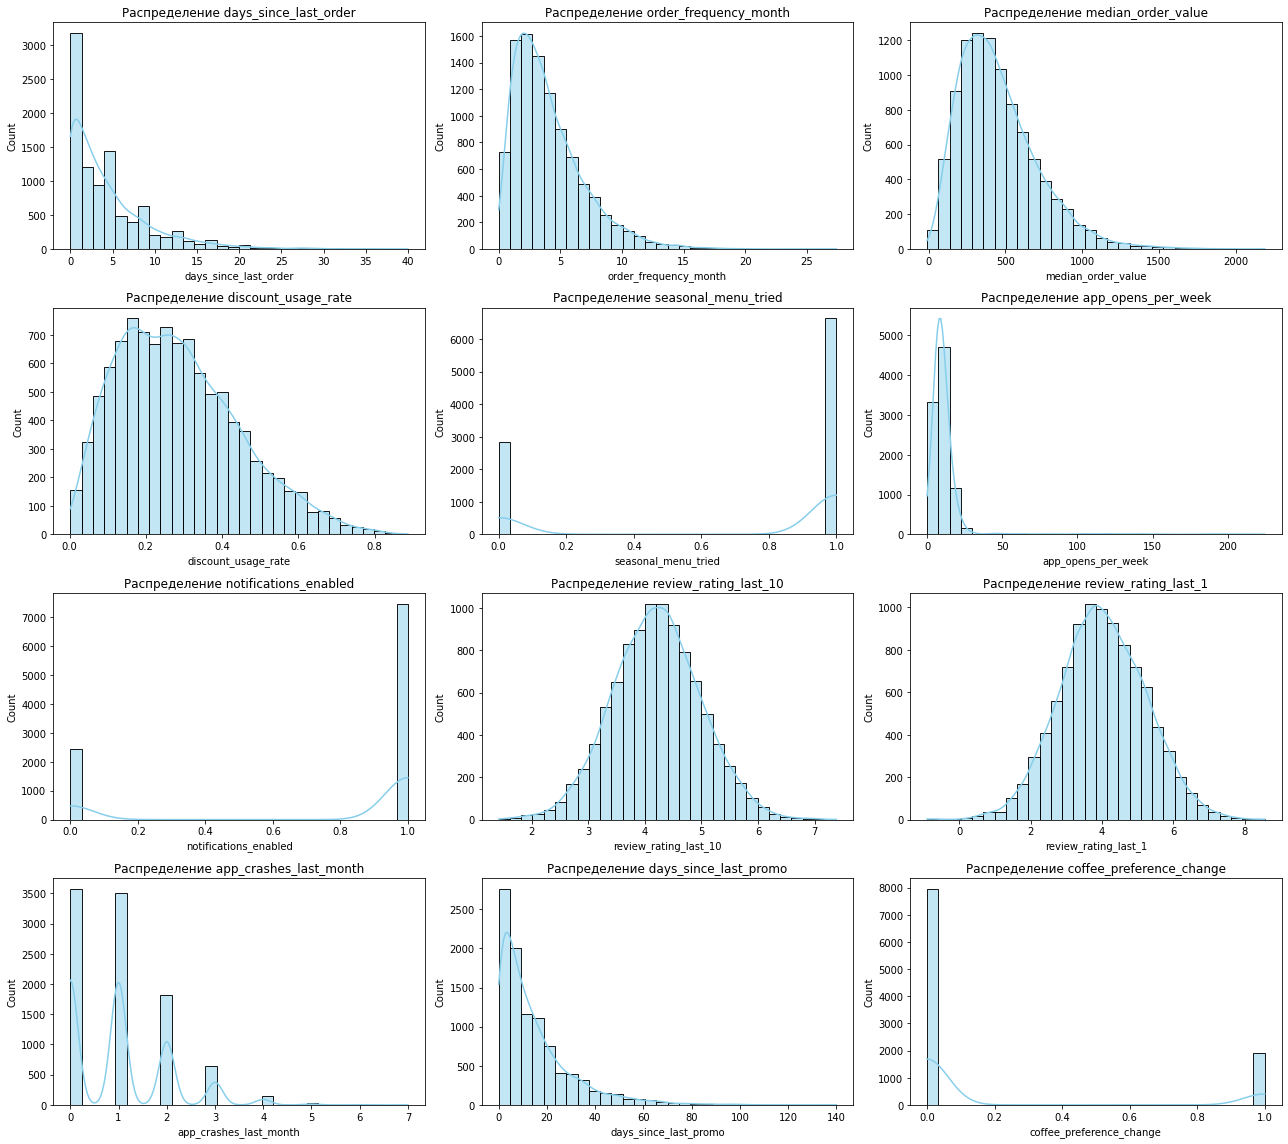

Максимальное значение order_frequency_month: 27.389317533750013


In [23]:
# Исправления, дополнения, поправки по комментариям (добавил просмотр по признакам, для точности анализа)
# ---------------------------------------------------------
# визуализируем 
num_cols_all = df_filtred.select_dtypes(include=['number']).columns.tolist()
if 'churn' in num_cols_all: num_cols_all.remove('churn')

# гистограммы для всех числовых признаков
n_cols = 3
n_rows = math.ceil(len(num_cols_all) / n_cols)

plt.figure(figsize=(18, n_rows * 4))
for i, col in enumerate(num_cols_all, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df_filtred[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Распределение {col}')

plt.tight_layout()
plt.show()

# отдельно проверю максимум по заказам, чтобы подтвердить аномалию
print(f"Максимальное значение order_frequency_month: {df_filtred['order_frequency_month'].max()}")
# ---------------------------------------------------------

In [24]:
#размер 
print("Размер датасета:", df_filtred.shape)

Размер датасета: (10450, 22)


In [25]:
# перевроверю описание
df_filtred.describe()

,days_since_last_order,order_frequency_month,median_order_value,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,9619.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,452.651500,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,258.657571,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-10.353340,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,262.908598,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,406.456818,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,590.418070,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,2189.101644,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [26]:
# 1. Заменяем отрицательные значения на NaN, rating_drop
numeric_cols = df_filtred.select_dtypes(include=['number']).columns
cols_to_clean = [col for col in numeric_cols if col != 'rating_drop']

for col in cols_to_clean:
    df_filtred.loc[df_filtred[col] < 0, col] = np.nan

# Исправления, дополнения, поправки по комментариям (фильтрации по выбрсам решил убрать)
# ---------------------------------------------------------
# список с выбросами
#cols_with_outliers = ['app_opens_per_week', 'median_order_value']

#for col in cols_with_outliers:
#    # 99-й перцентиль 
#    limit = df_filtred[col].quantile(0.99)
#    df_filtred.loc[df_filtred[col] > limit, col] = limit
# 
# ---------------------------------------------------------

print("Размер датасета:", df_filtred.shape)

Размер датасета: (10450, 22)


**Промежуточный вывод:**
- В данных, обнаружены отрицательные значения. Они были обработаны, так как они будут "перетягивать" веса признаков на себя, что крайне отрицательно скажется на модели.
- Выбросы выглядят реалистично, хоть и немного пугающе на графиках.
-----------------
- На гистограммах видно, что большинство числовых признаков (например, median_order_value, app_opens_per_week) имеют положительное смещение (длинный правый хвост). Это означает, что есть небольшая группа клиентов с аномально высокой активностью.
- Нужно использовать трансформации (Логарифмирование или Корень) для признаков с «хвостами», чтобы они «сжимали» диапазон больших приближали распределение к нормальному. Это важно для модели, так как без этого некоторые признаки будут смещать "веса" на себя. 
-----------------
- Отрицательные значения нужно заменить пропусками, для дальнейшей обработки.
- В признаках app_opens_per_week и median_order_value выбросы смещают среднее значение и стандартное отклонение. Это заставляет модель "подстраиваться" под аномалии, их нужно отфильтровать.
- Различия в значениях (одни в единицах, другие в сотнях) нужно стандартизировать (использовать StandardScaler).

### 7 
Посчитайте корреляции между признаками. Постройте необходимые визуализации. Определите, есть ли признаки, которые можно убрать, на основании их корреляции с другими.


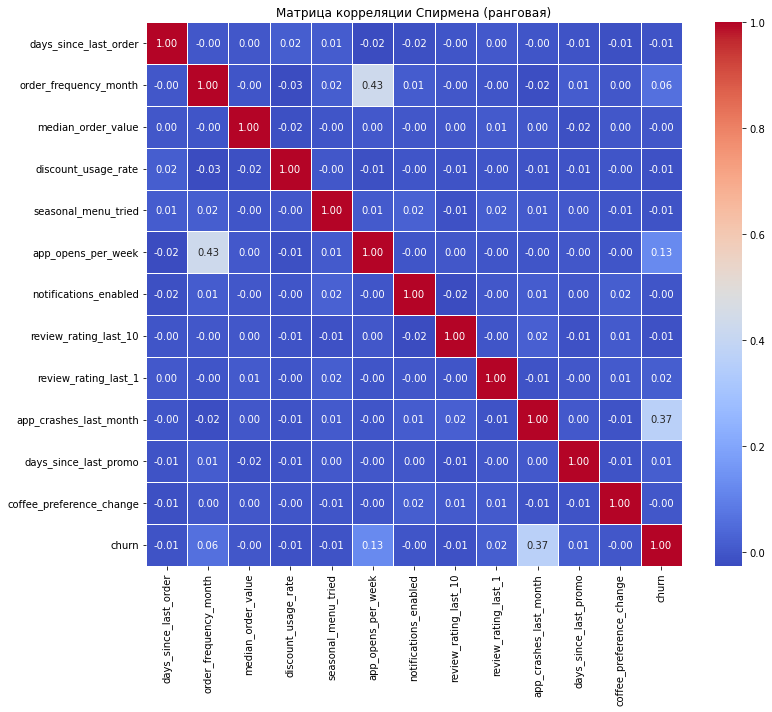

In [27]:
plt.figure(figsize=(12, 10))
sns.heatmap(df_filtred.corr(method='spearman', numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Матрица корреляции Спирмена (ранговая)')
plt.show()

**Промежуточный вывод:** 
- Мультиколинеальности между признаками нет, так как пододные призначи были удалены выше.

### 8
Напишите выводы по результатам исследовательского анализа данных.

**Выводы:**

**Обзор данных и целевой переменной:**
- Исходный датасет содержит 10 450 записей. В целевой переменной churn наблюдается сильный дисбаланс классов: доля ушедших клиентов составляет всего +-6%. Из-за дисбаланса основной метрикой качества для модели выбрана PR AUC.

**Отбор признаков (Feature Selection):**
- В ходе корреляционного анализа была выявлена сильная мультиколлинеарность. Для повышения стабильности модели были удалены дублирующие метрики: order_frequency_week, avg_order_value, total_spent_last_month и total_spent_last_week. Также исключены неинформативный признак user_id.

**Обработка аномалий и выбросов:**
- Выявлены ошибки в виде отрицательных значений в числовых признаках (чеки, рейтинги). Для сохранения объема выборки они были заменены на NaN. Выбросы в признаках app_opens_per_week и median_order_value были оставлены, они будут логарифмированы или извлечены из квадратного корня.

**Генерация признаков:**
- На основе имеющихся данных сформулированы новые метрики: rating_drop (падение удовлетворенности клиента) и promo_res (реакция на скидочные акции)(будут созданы ниже).

**План дальнейшей предобработки:**
- Оставшиеся пропуски в данных будут заполнены внутри Pipeline: для числовых признаков — медианой, для категориальных — модой (за исключением статуса подписки, там будет использоваться 'none'). Категориальные признаки будут закодированы методом One-Hot Encoding, а числовые масштабированы с помощью StandardScaler. geo_location - TargetEncoder

-----------------

## Этап 3. Предобработка данных

1. Разделите данные в пропорции 80 к 20. 20% данных отложите для теста. Остальные используйте для обучения и кросс-валидации модели.

2. Предобработайте данные. Используйте информацию о пропусках и категориальных признаках только из обучающей выборки.

   - Создайте пайплайн, который обработает пропуски и выбросы.

   - Создайте пайплайн, который обработает категориальные признаки.

   - Создайте пайплайн, который обработает числовые признаки: проведёт масштабирование и нормализацию.



### 1)

In [28]:
# выведу признаки, для удобства
df_filtred.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   days_since_last_order     9505 non-null   float64
 1   order_frequency_month     9850 non-null   float64
 2   median_order_value        9617 non-null   float64
 3   discount_usage_rate       10053 non-null  float64
 4   last_coffee_type          10192 non-null  object 
 5   preferred_roast           10334 non-null  object 
 6   milk_preference           9782 non-null   object 
 7   seasonal_menu_tried       9461 non-null   float64
 8   coffee_bean_origin        9768 non-null   object 
 9   last_drink_size           9946 non-null   object 
 10  subscription_status       9512 non-null   object 
 11  app_opens_per_week        9554 non-null   float64
 12  notifications_enabled     9913 non-null   float64
 13  review_rating_last_10     9757 non-null   float64
 14  review

In [29]:
# делим на категориальные признаки
cat_columns = ['last_coffee_type', 'preferred_roast', 'milk_preference', 
                                       'coffee_bean_origin', 'last_drink_size',
                                       'seasons', 'phone_type']
# числовые
num_columns = ['days_since_last_order', 'order_frequency_month', 'median_order_value', 
                                        'seasonal_menu_tried', 'app_opens_per_week', 'notifications_enabled', 
                                        'app_crashes_last_month', 'coffee_preference_change', 'days_since_last_promo', 
                                        'discount_usage_rate', 'review_rating_last_10', 'review_rating_last_1']

# категориальный, но со своей обработкой
spec_columns = ['subscription_status']
geo_column = ['geo_location']

# -------------------

# разделяем признаки и целевую переменную
X = df_filtred.drop(columns=["churn"])
y = df_filtred["churn"]

# -------------------

# делаем выборку
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,y,
    test_size = 0.2,
    stratify=y,
    random_state = RANDOM_STATE
)

# проверим размеры
print(f"Размер обучающей выборки: {X_train_val.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Доля положительного класса в train: {y_train_val.mean():.3f}")
print(f"Доля положительного класса в test: {y_test.mean():.3f}")

Размер обучающей выборки: (8360, 21)
Размер тестовой выборки: (2090, 21)
Доля положительного класса в train: 0.060
Доля положительного класса в test: 0.060


### 2)

In [30]:
# ----------------------------
# pipeline обработает пропуски и выбросы.
pipeline_num = Pipeline(steps = [
    ('imputer_num', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ----------------------------

# ----------------------------
# pipeline обработает категориальные признаки.
pipeline_cat = Pipeline(steps = [
    ('imputer_cat', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first')),
])

# ----------------------------

# пайплайн для geo
pipeline_geo = Pipeline(steps=[
    ('imputer_geo', SimpleImputer(strategy='most_frequent')), # или константа 'unknown'
    ('encoder_geo', TargetEncoder(smooth="auto", random_state=RANDOM_STATE))
])

# ----------------------------
# pipeline который обработает отдельный признак.
pipeline_spec = Pipeline(steps = [
    ('imputer_spec', SimpleImputer(strategy='constant', fill_value='none')),
    ('encoder_spec', OneHotEncoder(drop='first'))
])

# ----------------------------

# Трансформер (прайм)
processor = ColumnTransformer(transformers = [
    ('num', pipeline_num, num_columns),
    ('cat', pipeline_cat, cat_columns),
    ('spec', pipeline_spec, spec_columns),
    ('geo', pipeline_geo, geo_column)
])

**Промежуточный вывод:**
- Данные разделены на train, test.
- Сделаны пайплайны для обработки данных.

## Этап 4. Обучение модели

1. Обучите базовую версию модели.
   - Используйте для этого простые статистические модели.

   - Используйте кросс-валидацию для обучения модели.

2. Посчитайте метрики, поставленные в задаче. Опираясь на них, сделайте вывод о качестве модели.

### 1)

In [31]:
# обучение базойвой модели
full_pipeline_base = Pipeline(steps=[
    ('preprocessor', processor), 
    ('classifier', LogisticRegression(random_state=RANDOM_STATE)) 
])

# настройка кросс-валидации
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
results_base = cross_validate(
    estimator=full_pipeline_base,               # pipeline
    X=X_train_val,                                   # признаки
    y=y_train_val,                                   # целевая переменная
    scoring=['average_precision', 'f1'],   # список метрик
    cv=cv,                                 # стратегия разбиения
    return_train_score = True,             # расчёт качества на трейне
    return_estimator = True,               # сохранение обученных экземпляров модели
    n_jobs=-1                              # использовать все ядра
)

### 2)

In [32]:
# Выводим метрики 
print("PR_AUC:", np.round(results_base["test_average_precision"], 3))   
print('PR_AUC.mean:', np.mean(results_base["test_average_precision"]).round(3))
print("\nF1:", np.round(results_base["test_f1"], 3))
print('F1.mean:', np.mean(results_base["test_f1"]).round(3))

PR_AUC: [0.617 0.656 0.642 0.746 0.668]
PR_AUC.mean: 0.666

F1: [0.491 0.614 0.483 0.615 0.521]
F1.mean: 0.545


**Промежуточный вывод**:
- Базовая модель логистической регрессии демонстрирует способность предсказывать отток (средний PR_AUC 0.66).

## Этап 5. Создание новых признаков

1. Добавьте новые признаки, которые могут улучшить качество модели. Опирайтесь на наработки, полученные в ходе исследовательского анализа данных, и на логику решаемой задачи.

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

2. Обновите пайплайн для работы с новыми признаками, проведите повторную кросс-валидацию, сравните результаты моделей с новыми признаками и без них.

3. Интерпретируйте коэффициенты модели, а затем на их основании выявите значимые признаки и удалите лишние для модели.

### 1)

In [33]:
# Создаем новые признаки
df_filtred['app_crashes_last_month_squared'] = df_filtred['app_crashes_last_month']**2
df_filtred['rating_drop'] = df_filtred['review_rating_last_10'] - df_filtred['review_rating_last_1']
df_filtred['promo_res'] = df_filtred['discount_usage_rate'] / (df_filtred['days_since_last_promo'] + 1)
df_filtred['log_app_opens_per_week'] = np.log1p(df_filtred['app_opens_per_week'].clip(lower=0)) 
df_filtred['log_median_order_value'] = np.log1p(df_filtred['median_order_value'].clip(lower=0)) 

# новый список
num_columns_exp = [
    'days_since_last_order', 'order_frequency_month', 'median_order_value', 
    'seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change', 
    'rating_drop', 'promo_res', 'app_crashes_last_month', 'app_opens_per_week',
    'app_crashes_last_month_squared', 'log_app_opens_per_week', 'log_median_order_value'
]

# Обновляем признаки 
X_exp = df_filtred.drop(columns=["churn"])
y_exp = df_filtred["churn"]

# Разделяем на выборки
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(
    X_exp, y_exp,
    test_size=0.2,
    stratify=y_exp,
    random_state=RANDOM_STATE
)

**Вывод:**

- Логарифмировал app_opens_per_week и median_order_value для сжатия хвостов, чтобы было более симитричное распределение и не такое сильное влияние весов
- Возвёл в квадрат app_crashes_last_month, чтобы увеличить внимание модели к данному, достаточно важному признаку
- rating_drop выявляет падение рейтинга, а promo_res — степень его зависимости от маркетинговых акций.

### 2)

In [34]:
# обновляем трансформер
processor_exp = ColumnTransformer(transformers = [
    ('num', pipeline_num, num_columns_exp),
    ('cat', pipeline_cat, cat_columns),
    ('spec', pipeline_spec, spec_columns),
    ('geo', pipeline_geo, geo_column)
])

# обучение модели
full_pipeline_base_exp = Pipeline(steps=[
    ('processor', processor_exp), 
    ('classifier', LogisticRegression(random_state=RANDOM_STATE)) 
])

# настройка кросс-валидации
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
results_base_exp = cross_validate(
    estimator=full_pipeline_base_exp,               # pipeline
    X=X_train_exp,                                   # признаки
    y=y_train_exp,                                   # целевая переменная
    scoring=['average_precision', 'f1'],   # список метрик
    cv=cv,                                 # стратегия разбиения
    return_train_score = True,             # расчёт качества на трейне
    return_estimator = True,               # сохранение обученных экземпляров модели
    n_jobs=-1                              # использовать все ядра
)

# Выводим метрики 
print("PR_AUC:", np.round(results_base_exp["test_average_precision"], 3))   
print('PR_AUC.mean:', np.mean(results_base_exp["test_average_precision"]).round(3))
print("\nF1:", np.round(results_base_exp["test_f1"], 3))
print('F1.mean:', np.mean(results_base_exp["test_f1"]).round(3))

PR_AUC: [0.678 0.675 0.711 0.807 0.721]
PR_AUC.mean: 0.718

F1: [0.604 0.632 0.584 0.716 0.595]
F1.mean: 0.626


**Вывод:**
- Был обновлён трансформер и заново обучена модель, для проверки новых признаков.
- Добавление новых признаков и логарифмирование других дало прирост: PR_AUC увеличился на 5%, а F1-мера — на 8%. 

### 3)

In [35]:
# первый обученный пайплайн
fitted_pipe = results_base_exp['estimator'][0]

# имена признаков 
feature_names = fitted_pipe.named_steps['processor'].get_feature_names_out()

# коэффициенты 
coefs = fitted_pipe.named_steps['classifier'].coef_[0]

# таблица
importance = pd.DataFrame({'feature': feature_names, 'coef': coefs})
importance['abs_coef'] = importance['coef'].abs()
importance = importance.sort_values(by='abs_coef', ascending=False)

print(importance.head(15))

                                feature      coef  abs_coef
10  num__app_crashes_last_month_squared  1.870267  1.870267
11          num__log_app_opens_per_week  1.668874  1.668874
36        spec__subscription_status_pro  0.815982  0.815982
9               num__app_opens_per_week -0.775535  0.775535
17            cat__milk_preference_none -0.719844  0.719844
33                  cat__phone_type_web -0.555091  0.555091
14        cat__last_coffee_type_robusta  0.507528  0.507528
20             cat__milk_preference_soy -0.449334  0.449334
19            cat__milk_preference_skim -0.400285  0.400285
21           cat__milk_preference_whole -0.288476  0.288476
23     cat__coffee_bean_origin_ethiopia  0.281640  0.281640
1            num__order_frequency_month  0.251031  0.251031
16          cat__preferred_roast_medium -0.230603  0.230603
32                  cat__phone_type_ios -0.211673  0.211673
18             cat__milk_preference_oat -0.201331  0.201331


**Вывод**
- Нужно удалить признаки app_opens_per_week и app_crashes_last_month, чтобы устранить мультиколлинеарность и сделать модель устойчивей

In [36]:

num_columns_final = [
    'days_since_last_order', 'order_frequency_month', 'median_order_value', 
    'seasonal_menu_tried', 'notifications_enabled', 'coffee_preference_change', 
    'rating_drop', 'promo_res', 'app_crashes_last_month_squared', 
    'log_app_opens_per_week', 'log_median_order_value']

processor_final = ColumnTransformer(transformers = [
    ('num', pipeline_num, num_columns_final),
    ('cat', pipeline_cat, cat_columns),
    ('spec', pipeline_spec, spec_columns),
    ('geo', pipeline_geo, geo_column)
])

full_pipeline_final = Pipeline(steps=[
    ('preprocessor', processor_final), 
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)) 
])

results_final = cross_validate(
    estimator=full_pipeline_final,              # pipeline
    X=X_train_exp,                                   # признаки
    y=y_train_exp,                                   # целевая переменная
    scoring=['average_precision', 'f1'],   # список метрик
    cv=cv,                                 # стратегия разбиения
    return_train_score = True,             # расчёт качества на трейне
    return_estimator = True,               # сохранение обученных экземпляров модели
    n_jobs=-1                              # использовать все ядра
)

print('Финальный PR_AUC mean:', np.mean(results_final["test_average_precision"]).round(3))
print('Финальный F1 mean:', np.mean(results_final["test_f1"]).round(3))

Финальный PR_AUC mean: 0.698
Финальный F1 mean: 0.59


**Промежуточный вывод:**
- Созданы новые признаки.
- Анализ коэффициентов логистической регрессии показал мультиколлинеарность между исходными и новыми признаками (у app_opens и его корня были высокие веса с противоположными знаками), поэтому оригинальные признаки были удалены.
- Финальная модель показала прирост качества по сравнению с базовой (PR_AUC вырос с 0.666 до 0.698, F1 с 0.545 до 0.59).

## Этап 6. Эксперименты с гиперпараметрами

1. Перечислите все гиперпараметры, с которыми планируете экспериментировать.

2. Проведите систематический перебор гиперпараметров для `LogisticRegression`, выполните кросс-валидацию для каждой конфигурации.

3. Составьте таблицу с результатами.

4. Выберите лучшую модель, ориентируясь на заданную метрику качества.

### 1)

In [37]:
# список параметров для тестов
hyperparams = []

for c in [0.1, 1.0, 10.0]:
    for penalty in ['l1', 'l2']:
        for weight in [None, 'balanced']:
            hyperparams.append({
                'C': c, 
                'penalty': penalty, 
                'class_weight': weight
            })

- C: сила регуляризации. Чем меньше C, тем сильнее мы «штрафуем» модель за сложные веса. Попробую: [0.1, 1.0, 10.0.]
- penalty: тип штрафа. попробую классический 'l2' и 'l1'.
- class_weight: сравню balanced и none 

### 2)

In [38]:
# Список для результатов
tuning_stats = []

for params in hyperparams:
    # модель с текущими параметрами
    model = Pipeline(steps=[
        ('preprocessor', processor_final),
        ('classifier', LogisticRegression(
            random_state=RANDOM_STATE, 
            max_iter=1000,
            C=params['C'],
            penalty=params['penalty'],
            class_weight=params['class_weight'],
            solver='liblinear' # поддерживает и L1, и L2
        ))
    ])
    
    # кросс-валидация
    cv_results = cross_validate(
        model, X_train_exp, y_train_exp, 
        cv=cv, 
        scoring=['average_precision', 'f1'],
        n_jobs=-1
    )
    
    # сохраненеия результятов
    tuning_stats.append({
        'C': params['C'],
        'penalty': params['penalty'],
        'class_weight': params['class_weight'],
        'PR_AUC': np.mean(cv_results['test_average_precision']),
        'F1': np.mean(cv_results['test_f1'])
    })

print("Эксперименты завершены.")

Эксперименты завершены.


### 3)

In [39]:
# делаем датафрейм
tuning_results = pd.DataFrame(tuning_stats)

# сортирую по PR_AUC 
tuning_results = tuning_results.sort_values(by='PR_AUC', ascending=False).reset_index(drop=True)

print("Результаты экспериментов (Топ-10):")
print(tuning_results.head(10))

Результаты экспериментов (Топ-10):
      C penalty class_weight    PR_AUC        F1
0   0.1      l1         None  0.700922  0.585987
1   1.0      l1         None  0.698936  0.587493
2   1.0      l2         None  0.698003  0.588965
3  10.0      l1         None  0.696922  0.593052
4  10.0      l2         None  0.696788  0.593052
5   0.1      l1     balanced  0.694614  0.491631
6   0.1      l2         None  0.693019  0.578249
7   0.1      l2     balanced  0.690802  0.483255
8   1.0      l1     balanced  0.689532  0.483074
9   1.0      l2     balanced  0.688731  0.479839


### 4)

**Лучшая модель:**
- Строка 0 (C=0.1, penalty='l1', class_weight=None). У неё самый высокий PR_AUC (0.7).

**Параметры:**
- C: 0.1
- Penalty: 'l1'
- Class_weight: None
- Solver: 'liblinear'

**Вывод:**
- Параметр регуляризации говорит нам о том, что модель не пытается идеально подстроиться под каждый выброс в тренировочных данных, что делает её более устойчивой.

## Этап 7. Подготовка финальной модели

Объедините лучшую конфигурацию гиперпараметров с оптимальным набором признаков. Обучите модель на всех данных для кросс-валидации и проведите финальную оценку на отложенной тестовой выборке.


In [40]:
# строим финальную модель
final_model = Pipeline(steps=[
    ('preprocessor', processor_final), 
    ('classifier', LogisticRegression(
        random_state=RANDOM_STATE, 
        max_iter=1000,
        C=0.1,
        penalty='l1',
        class_weight=None,
        solver='liblinear'
    ))
])

# обучение на всех данных для кросс-валидации 
final_model.fit(X_train_exp, y_train_exp)

# получение предсказаний на отложенной тестовой выборке
y_test_proba = final_model.predict_proba(X_test_exp)[:, 1]
y_test_pred = final_model.predict(X_test_exp)

# оценка метрик
test_pr_auc = average_precision_score(y_test_exp, y_test_proba)
test_f1 = f1_score(y_test_exp, y_test_pred)

print(f"Финальный PR-AUC на тесте: {test_pr_auc:.3f}")
print(f"Финальный F1-score на тесте: {test_f1:.3f}")

Финальный PR-AUC на тесте: 0.746
Финальный F1-score на тесте: 0.621


## Этап 8. Отчёт о проделанной работе

Проанализируйте итоговые метрики модели и факторы, которые на них повлияли. Составьте описание, выделив наиболее важные факторы.

-------
**Анализ итоговых метрик:**
- PR-AUC на тестовой выборке: 0.746
- Модель показала хорошую стабильность и прирост качества по сравнению с базовой версией (PR-AUC вырос с 0.668 до 0.746).


- F1-score на тестовой выборке: 0.621
- Модель находит баланс между точностью и полнотой, минимизируя как пропуски уходящих клиентов, так и ложные срабатывания.

**Факторы, влияющие на отток:**
- Частота использования приложения (sqrt_app_opens_per_week):
- Самый весомый фактор. Пользователи, которые заходят в приложение слишком часто, имеют более высокий риск ухода.


- Краш приложения (app_crashes_last_month_squared):
- Увеличение числа сбоев критически бьет по лояльности.


- Статус лояльности (subscription_status_pro):
- PRO-пользователи оказались наиболее склонны к оттоку.


- Вкусовые предпочтения (milk_preference_none):
- Любители черного кофе демонстрируют самую высокую приверженность.
-------

**Вывод по модели:**
- Финальная модель достигла показателей (PR-AUC = 0.747), что позволяет использовать её для автоматической идентификации клиентов из группы риска. 
- Рекомендация: настроить коммуникации: если у пользователя зафиксировано >2 крашей или он резко снизил рейтинг заказа — система должна автоматически предлагать ему бонус на следующий визит или предлагать связать его с отделом поддержки, чтобы решить проблемы.

## Этап 9. Сохранение модели для продакшена

Сохраните итоговую модель и пайплайн предобработки. Убедитесь, что всё работает: загрузите артефакты и проверьте их на тестовых данных. В решении укажите ссылку для скачивания сохранённых файлов.

In [43]:
# сохраняем
filename = 'models/churn_model.joblib'
joblib.dump(final_model, filename)
print(f"Модель сохранена в файл: {filename}")

# проверка работы, загружаем
loaded_model = joblib.load('models/churn_model.joblib')

# проверяем, делаем предсказание загруженной моделью
y_loaded_proba = loaded_model.predict_proba(X_test_exp)[:, 1]

# метрики
loaded_pr_auc = average_precision_score(y_test_exp, y_loaded_proba)

print(f"PR-AUC исходной модели: {test_pr_auc:.3f}")
print(f"PR-AUC загруженной модели: {loaded_pr_auc:.3f}")

if round(test_pr_auc, 3) == round(loaded_pr_auc, 3):
    print("Результаты индентичны")
else:
    print("результаты не совпадают, ошибка.")

Модель сохранена в файл: models/churn_model.joblib
PR-AUC исходной модели: 0.746
PR-AUC загруженной модели: 0.746
Результаты индентичны
